In [112]:
import pandas as pd
from analysis_utils import build_all_analyses, build_summary_csv

In [113]:
# Todo once: build analysis file for each run type and map, saved under data/analysis_per_map by default
#build_all_analyses()

# Todo once: build (and call) summary csv file with metrics for each experimental and simulation case
df = build_summary_csv()
df2 = pd.read_csv("../data/summary_statistics.csv") # Otherwise, read it

Saved summary CSV: ../data/summary_statistics.csv


In [114]:
df2

,map,source,first,last,gap,average,total,aggregate_welfare,gap_normalized,gini
0,10esque,line,21.00,77.00,56.00,49.0000,392.00,0.000000,0.000000,0.214286
1,10esque,1cut,21.00,77.00,56.00,49.0000,392.00,0.000000,0.000000,0.214286
2,10esque,paper_data,29.80,108.60,78.80,67.0500,536.40,-1.875325,0.296104,0.222280
3,10esque,level-1,28.58,108.04,79.46,66.9500,535.60,-1.864935,0.304675,0.225047
4,10esque,level-0,29.18,105.66,76.48,64.7025,517.62,-1.631429,0.265974,0.223117
...,...,...,...,...,...,...,...,...,...,...
146,yes_line_E,level-0,37.52,102.10,64.58,69.9725,559.78,-2.835161,0.590000,0.177035
147,yes_line_F,line,44.00,51.00,7.00,47.5000,380.00,0.000000,0.000000,0.027632
148,yes_line_F,1cut,34.00,49.00,15.00,44.5000,356.00,0.470588,0.156863,0.049157
149,yes_line_F,paper_data,26.20,101.00,74.80,62.8000,502.40,-2.400000,1.329412,0.216382


In [115]:
def map_category(name: str) -> str:
    if name.startswith("no_line"):
        return "no_line"
        
    elif name.startswith("yes_line_"):
        return "yes_line"

    else:
        return "maybe"


def map_subcategory(name: str) -> str:
    if name.startswith("no_line"):
        suffix = name.split("no_line_")[1]
        if suffix and suffix[-1].isdigit():
            return "no_line_number"    # e.g. no_line_1, no_line_10
        elif suffix and suffix[-1].isalpha():
            return "no_line_letter" # e.g. no_line_A, no_line_B
        
    elif name.startswith("yes_line_"):
        suffix = name.split("yes_line_")[1]
        if suffix and suffix[-1].isdigit():
            return "yes_line_number"
        elif suffix and suffix[-1].isalpha():
            return "yes_line_letter"

    elif name.startswith("maybe"):
        return "maybe"
    elif name.startswith("new_maybe"):
        return "new_maybe"
    elif "esque" in name:
        return "esque"

In [122]:
df["map_type"] = df["map"].apply(map_category)
df["map_subtype"] = df["map"].apply(map_subcategory)

df2["map_type"] = df2["map"].apply(map_category)
df2["map_subtype"] = df2["map"].apply(map_subcategory)

#line_df = df [ df["source"] == "line"]
#line_df["map_type"].value_counts() # 29 in total, seems good
#line_df["map_subtype"].value_counts() # 29 in total, seems good

In [123]:
def pivot_metric(df, metric: str):
    """
    Return a wide table:
        index = map
        columns = source
        values = metric
    """
    wide = df.pivot(index="map", columns="source", values=metric)
    return wide
wide_aw = pivot_metric(df, "aggregate_welfare")
wide_aw.head()


source,1cut,1cut_bad,1cut_badder,level-0,level-1,line,paper_data
map,,,,,,,
10esque,0.000000,NaN,NaN,-1.631429,-1.864935,0.0,-1.875325
7esque,0.000000,NaN,NaN,-1.431111,-1.597778,0.0,-1.582222
9esque,0.437500,NaN,NaN,-1.456250,-1.592917,0.0,-1.658333
maybe_4,0.604651,NaN,NaN,0.232093,0.188837,0.0,0.255814
maybe_5,0.603448,NaN,NaN,0.861034,0.682759,0.0,0.868966


In [143]:
import matplotlib.pyplot as plt
import seaborn as sns

def scatter_compare_sources(
    df,
    metric,
    source_x,
    source_y,
    title,
    xlabel,
    ylabel,
    save_path = None,
    show_ci_plot=False,
):
    """
    Compare one metric across two sources:
        x-axis: metric for source_x
        y-axis: metric for source_y
    One point per map, colored by map_type.
    """
    # 1) Wide table for the chosen metric
    wide = pivot_metric(df, metric)

    # Keep only maps where both sources are present
    if source_x not in wide.columns or source_y not in wide.columns:
        raise ValueError(f"One of sources {source_x}, {source_y} not found in columns {list(wide.columns)}")

    wide = wide[[source_x, source_y]].dropna()

    # 2) Attach map_type (using 'line' rows or from df more generally)
    # We’ll take map_type from any row for that map (line is a good candidate)
    map_types = (
        df
        .drop_duplicates(subset=["map"])
        [["map", "map_type", "map_subtype"]]
        .set_index("map")
    )

    wide = wide.join(map_types, how="left")

    # Rename columns for plotting
    wide = wide.reset_index().rename(
        columns={
            source_x: f"{metric} ({source_x})",
            source_y: f"{metric} ({source_y})",
        }
    )

    x_col = f"{metric} ({source_x})"
    y_col = f"{metric} ({source_y})"

    # 3) Define colors for macro groups (3 colors)
    macro_palette = {
        "no_line": "tab:blue",
        "yes_line": "tab:red",
        "maybe": "tab:green"
    }
    # Markers per fine category
    marker_map = {
        "no_line_number": "o",
        "no_line_letter": "x",
        "yes_line_number": "o",
        "yes_line_letter": "x",
        "esque": "s",
        "maybe": "o",
        "new_maybe": "x"
    }

    # Desired order in legend
    fine_order = [
        "no_line_number",
        "no_line_letter",
        "yes_line_number",
        "yes_line_letter",
        "esque",
        "maybe",
        "new_maybe",
    ]
    
    # 4) Scatter with hue = macro (color), style = fine (marker)
    fig, ax = plt.subplots(figsize=(7, 6))

    for fine_cat in fine_order:
        sub = wide[wide["map_subtype"] == fine_cat]
        if sub.empty:
            continue
        macro = sub["map_type"].iloc[0]  # all same by construction
        color = macro_palette.get(macro, "tab:gray")
        marker = marker_map.get(fine_cat, "o")

        plt.scatter(
            sub[x_col],
            sub[y_col],
            label=fine_cat,   # we'll override legend later, but good to set
            color=color,
            marker=marker,
            s=70,
            alpha=0.9,
        )

    # Add a simple global regression line (no CI) using seaborn but no hue
    sns.regplot(
        data=wide,
        x=x_col,
        y=y_col,
        scatter=False,
        color="black",
        line_kws={"linewidth": 1.5, "alpha": 0.8},
    )

    if title is None:
        title = f"{metric}: {source_y} vs {source_x}"
    plt.title(title)
    plt.xlabel(xlabel or x_col)
    plt.ylabel(ylabel or y_col)

    plt.axline((0, 0), slope=1, linestyle="--", linewidth=1, alpha=0.5)  # identity line
    plt.legend()
    fig.tight_layout()

    if save_path is not None:
        fig.savefig(save_path, dpi=300, bbox_inches="tight")

    plt.show()

    # 4) Optional second plot: clean regression with CI (no grouping)
    if show_ci_plot:
        plt.figure(figsize=(7, 6))
        sns.regplot(
            data=wide,
            x=x_col,
            y=y_col,
            ci=95,          # 95% CI band around regression line
            scatter_kws={"s": 60, "alpha": 0.7},
            line_kws={"linewidth": 2},
        )
        plt.axline((0, 0), slope=1, linestyle="--", linewidth=1, alpha=0.5)
        plt.title(f"{metric}: regression with 95% CI\n{source_y} vs {source_x}")
        plt.tight_layout()

        plt.show()

    return wide

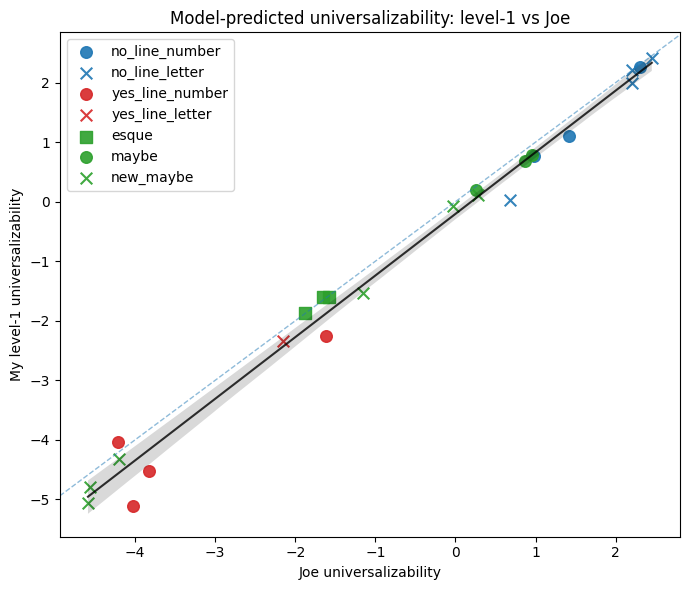

In [144]:
uni_1_joe = scatter_compare_sources(
    df,
    metric="aggregate_welfare",
    source_x="paper_data",
    source_y="level-1",
    title="Model-predicted universalizability: level-1 vs Joe",
    xlabel="Joe universalizability",
    ylabel="My level-1 universalizability",
    save_path="plots/universalizability_1_joe.png",
    #show_ci_plot=True
)

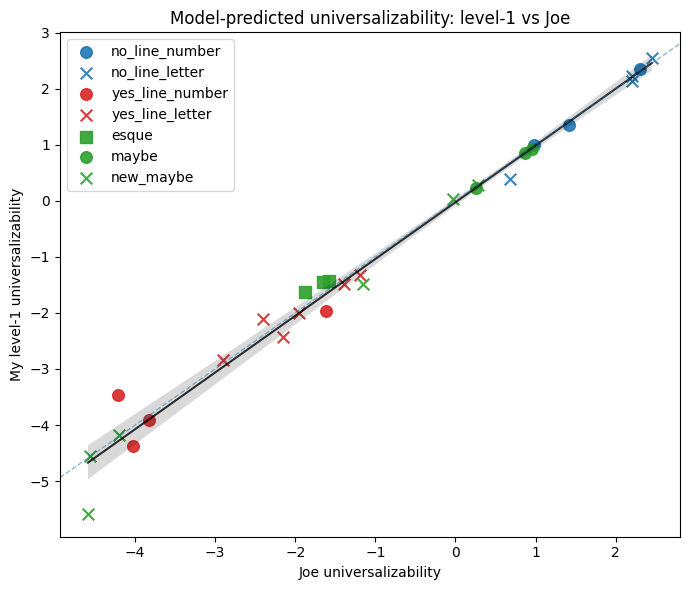

In [146]:
uni_0_joe = scatter_compare_sources(
    df,
    metric="aggregate_welfare",
    source_x="paper_data",
    source_y="level-0",
    title="Model-predicted universalizability: level-1 vs Joe",
    xlabel="Joe universalizability",
    ylabel="My level-1 universalizability",
    save_path="plots/universalizability_0_joe.png"
)

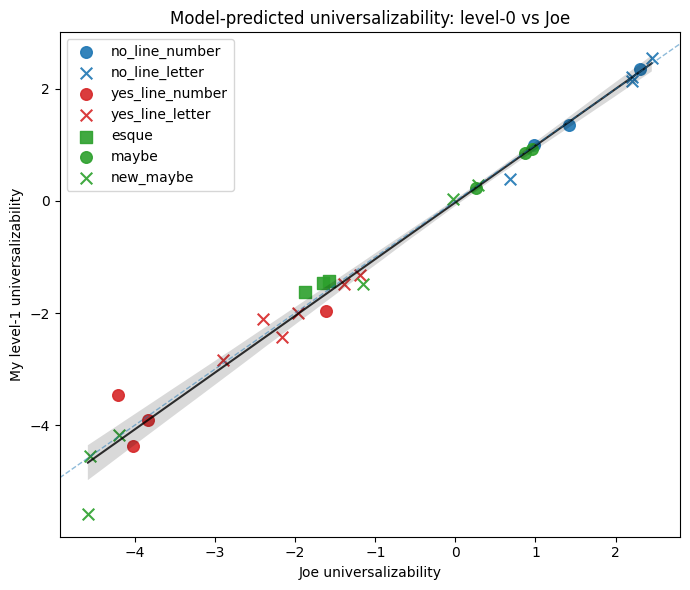

In [109]:
wide_aw_paper_vs_lvl0 = scatter_compare_sources(
    df,
    metric="aggregate_welfare",
    source_x="paper_data",
    source_y="level-0",
    title="Model-predicted universalizability: level-0 vs Joe",
    xlabel="Joe universalizability",
    ylabel="My level-1 universalizability"
)

In [52]:
# 29
# 29
# 7
# 4
# 29
# 29
# 24 _---- TODO: 5 maps from level 1, still waiting